# Язык моря в британской маринистической литературе

Был вручную собран корпус из 39 британских текстов разных годов: от 1790 до 2023. Именно Великобритания была выбрана, поскольку это страна с крайне богатой историей мореплавания и флота, причем море до сих пор имеет очень большое значение в ее культуре

Все собранные книги имеют достаточно большой фокус на море, во многих действие происходит на кораблях или сосредоточено на моряках.
Эти книги были разделены на следующие временные периоды в соответствии с культурно-политическими событиями истории Великобритании и литературными течениями:

1790-1840 -- предвикторианская эпоха, в основном романтические тексты

1841-1900 -- викторианская эпоха, происходит переход от романтизма к реализму

1901-1944 -- период включает обе мировые войны, включает в себя модернисткие тексты

1945-1980 -- послевоенный период, зарождение постмодернизма

1981-2025 -- постколониальный и антиимпералистический период

Для каждого периода было отобрано 7-9 книг, причем были сделаны попытки сделать тексты одного периода как можно более разнообразными.

Книги также были поделены на следующие 3 жанра: нон-фикшн (в него входят как дневники и мемуары, так и тексты, написанными другими людьми), поэзия, художественная проза. Поскольку корпус текстов небольшой, более дробное деление привело бы к тому, что в некоторых жанрах всего 1-2 текста. Но даже для 3 жанров интересно будет посмотреть, существует ли в них разница в том, как описывается море.

### Подготовка текстов к анализу

In [47]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from razdel import tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
import nltk
from nltk.corpus import stopwords
import spacy
from collections import Counter
import numpy as np
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics.pairwise import cosine_similarity
from scipy.stats import pearsonr
from gensim.models import Word2Vec
import matplotlib.pyplot as plt


In [4]:
# таблица с метаданными (сделана вручную)
df = pd.read_csv('table.csv')

df.head(10)

,Произведение,Год,Период,Жанр
0,"A narrative of the mutiny, on board his majest...",1790,1790-1840,Нон-фикшн
1,The Rime of the Ancient Mariner,1797,1790-1840,Поэзия
2,The Corsair,1814,1790-1840,Поэзия
3,A Voyage Round Great Britain,1814,1790-1840,Нон-фикшн
4,The Pirate,1822,1790-1840,Художественная проза
5,The Island,1823,1790-1840,Поэзия
6,Mr Midshipman Easy,1836,1790-1840,Художественная проза
7,"Masterman Ready, or the Wreck of the Pacific",1841,1841-1900,Художественная проза
8,The Forsaken Merman,1849,1841-1900,Поэзия
9,Westward ho!,1855,1841-1900,Художественная проза


In [5]:
df['Название файла'] = (df['Произведение'].str.lower().str.replace(' ', '_') + '.txt')


In [6]:
def load_text(filename):
    with open(filename, 'r', encoding='utf-8') as f:
        return f.read()

# разделение текстов на токены
df['Текст'] = df['Название файла'].apply(load_text)
df['Токены'] = df['Текст'].apply(lambda t: [substring.text for substring in tokenize(t)])
df['Кол-во токенов'] = df['Токены'].apply(lambda tokens: len(tokens))

In [7]:
df.head()

,Произведение,Год,Период,Жанр,Название файла,Текст,Токены,Кол-во токенов
0,"A narrative of the mutiny, on board his majest...",1790,1790-1840,Нон-фикшн,"a_narrative_of_the_mutiny,_on_board_his_majest...","A\nNARRATIVE\nOF THE\nMUTINY,\nON BOARD\nHIS M...","[A, NARRATIVE, OF, THE, MUTINY, ,, ON, BOARD, ...",33746
1,The Rime of the Ancient Mariner,1797,1790-1840,Поэзия,the_rime_of_the_ancient_mariner.txt,\n\n\nTHE RIME OF THE ANCIENT MARINER\n\n\n\nI...,"[THE, RIME, OF, THE, ANCIENT, MARINER, IN, SEV...",4751
2,The Corsair,1814,1790-1840,Поэзия,the_corsair.txt,THE CORSAIR\nLORD BYRON\nTable of Contents\nTH...,"[THE, CORSAIR, LORD, BYRON, Table, of, Content...",5863
3,A Voyage Round Great Britain,1814,1790-1840,Нон-фикшн,a_voyage_round_great_britain.txt,"Full text of ""A voyage round Great Britain, un...","[Full, text, of, "", A, voyage, round, Great, B...",345805
4,The Pirate,1822,1790-1840,Художественная проза,the_pirate.txt,THE PIRATE.EDITOR’S INTRODUCTION\n\nINTRODUCTI...,"[THE, PIRATE, ., EDITOR, ’, S, INTRODUCTION, I...",241317


Проверим теперь, насколько корпус сбалансированный

In [48]:
period_stats = df.groupby('Период')['Кол-во токенов'].agg(['count', 'sum', 'mean']).sort_index()

In [49]:
period_stats

,count,sum,mean
Период,,,
1790-1840,7,826587,118083.857143
1841-1900,8,849594,106199.250000
1901-1944,7,570867,81552.428571
1945-1980,9,816313,90701.444444
1981-2025,8,688495,86061.875000


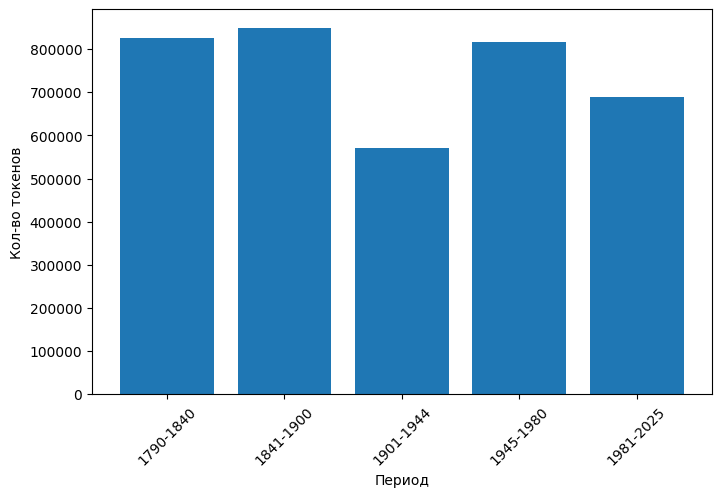

In [59]:
plt.figure(figsize=(8,5))

plt.bar(period_stats.index, period_stats['sum'])

plt.ylabel('Кол-во токенов')
plt.xlabel('Период')

plt.xticks(rotation=45)
plt.show()

Можно увидеть, что корпус получился не совсем сбалансированный по периодам, однако, скорее всего, достаточно, чтобы это не мешало никаким методам

In [56]:
genre_stats = df.groupby('Жанр')['Кол-во токенов'].agg(['count', 'sum', 'mean']).sort_index()
genre_stats

,count,sum,mean
Жанр,,,
Нон-фикшн,7,1019921,145703.000000
Поэзия,11,141387,12853.363636
Художественная проза,21,2590548,123359.428571


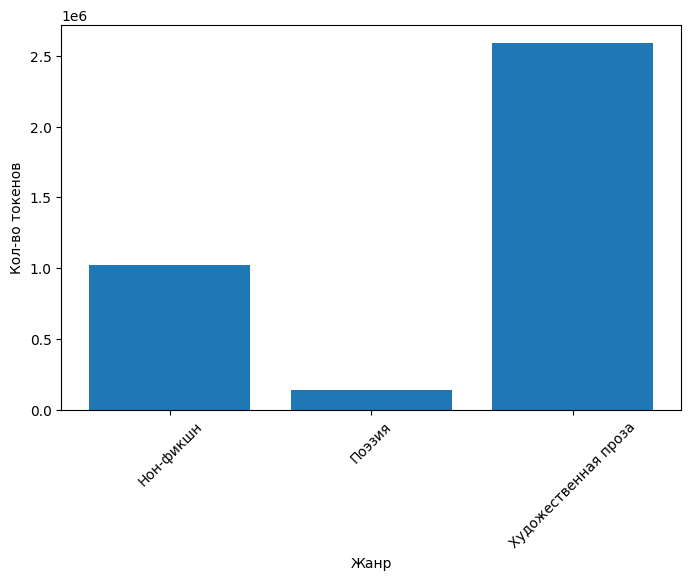

In [58]:
plt.figure(figsize=(8,5))

plt.bar(genre_stats.index, genre_stats['sum'])

plt.ylabel('Кол-во токенов')
plt.xlabel('Жанр')

plt.xticks(rotation=45)
plt.show()

Ожидаемо, по жанрам балланс уже сильно хуже - подкорпус поэзии оказался в разы меньше других. Разница между прозой и нон-фикшеном также превышает 2.5 раза. Поэтому на материале жанров не будут использоваться методы, для которых размер корпусов важен, например, word2vec

In [10]:
df.groupby(['Период', 'Жанр'])['Кол-во токенов'].sum()

Период     Жанр                
1790-1840  Нон-фикшн               379551
           Поэзия                   31804
           Художественная проза    415232
1841-1900  Нон-фикшн               202328
           Поэзия                   30058
           Художественная проза    617208
1901-1944  Нон-фикшн                70112
           Поэзия                   36196
           Художественная проза    464559
1945-1980  Нон-фикшн               113047
           Поэзия                   22892
           Художественная проза    680374
1981-2025  Нон-фикшн               254883
           Поэзия                   20437
           Художественная проза    413175
Name: Кол-во токенов, dtype: int64

Каждый из жанров присутствует во всех периодах, поэтому можно сравнивать тексты по жанрам, не боясь, что картина будет искажена периодами (нет такого, что поэзия присутствует только в романтическом периоде и лишь поэтому ее ключевые слова отличаются).

### TF-IDF анализ

In [11]:
period_texts = df.groupby('Период')['Текст'].apply(' '.join)

vectorizer = TfidfVectorizer(stop_words='english', lowercase=True)
tfidf_matrix = vectorizer.fit_transform(period_texts)
feature_names = vectorizer.get_feature_names_out()

periods_list = period_texts.index.tolist()

for i, year in enumerate(periods_list):
    row = tfidf_matrix[i].toarray().flatten()

    # 20 ключевых слов для каждого периода
    top_indices = row.argsort()[-20:][::-1]

    top_words = [(feature_names[j], round(row[j], 3)) for j in top_indices]

    print(f'\n{year}:')
    for word, score in top_words:
        print(f'  {word}: {score}')



1790-1840:
  said: 0.237
  jack: 0.193
  great: 0.18
  sea: 0.165
  mordaunt: 0.151
  mr: 0.145
  little: 0.138
  time: 0.137
  man: 0.135
  mesty: 0.123
  gascoigne: 0.122
  captain: 0.112
  like: 0.11
  round: 0.109
  replied: 0.099
  minna: 0.095
  men: 0.094
  cleveland: 0.092
  water: 0.09
  good: 0.09

1841-1900:
  amyas: 0.316
  said: 0.251
  like: 0.19
  man: 0.173
  seagrave: 0.165
  old: 0.156
  sir: 0.152
  mr: 0.152
  ready: 0.135
  little: 0.13
  men: 0.13
  time: 0.119
  sea: 0.118
  good: 0.108
  long: 0.105
  great: 0.101
  day: 0.098
  did: 0.094
  william: 0.093
  come: 0.089

1901-1944:
  said: 0.287
  hornblower: 0.226
  man: 0.178
  captain: 0.176
  blood: 0.175
  like: 0.172
  men: 0.165
  ship: 0.163
  did: 0.143
  sea: 0.136
  time: 0.125
  came: 0.116
  eyes: 0.102
  old: 0.1
  thought: 0.097
  little: 0.096
  come: 0.092
  away: 0.092
  mr: 0.091
  way: 0.09

1945-1980:
  said: 0.422
  like: 0.181
  sir: 0.17
  time: 0.167
  ship: 0.144
  lockhart: 0.13
  cap

Можно увидеть, что довольно большая часть ключевых слов для каждого периода - имена собственные (в основном персонажей романов). Поэтому я сделаю список стоп-слов, в который будут также включены эти имена. Проблема в том, что в некоторых случаях слово может быть как именем собственным, так и нарицательным - little/Little, blood/Blood и т.п. Для этого я отдельно посмотрела на слова в tf-idf(lowercase=False)

In [12]:
period_texts = df.groupby('Период')['Текст'].apply(' '.join)

# чтобы можно было отличить имена собственные от просто существительных/прилагательных
vectorizer = TfidfVectorizer(stop_words='english', lowercase=False)
tfidf_matrix = vectorizer.fit_transform(period_texts)
feature_names = vectorizer.get_feature_names_out()

periods_list = period_texts.index.tolist()

for i, year in enumerate(periods_list):
    row = tfidf_matrix[i].toarray().flatten()

    # 40 ключевых слов для каждого периода
    top_indices = row.argsort()[-40:][::-1]

    top_words = [(feature_names[j], round(row[j], 3)) for j in top_indices]

    print(f'\n{year}:')
    for word, score in top_words:
        print(f'  {word}: {score}')



1790-1840:
  The: 0.452
  said: 0.206
  Jack: 0.164
  sea: 0.141
  Mordaunt: 0.131
  Mr: 0.125
  It: 0.125
  time: 0.118
  little: 0.118
  ROUND: 0.113
  man: 0.112
  Mesty: 0.105
  Gascoigne: 0.105
  BRITAIN: 0.098
  great: 0.098
  And: 0.093
  like: 0.091
  But: 0.088
  replied: 0.086
  Minna: 0.082
  VOYAGE: 0.081
  men: 0.08
  Cleveland: 0.08
  He: 0.079
  water: 0.077
  long: 0.076
  In: 0.076
  GREAT: 0.076
  good: 0.073
  Norna: 0.073
  place: 0.072
  coast: 0.07
  country: 0.069
  small: 0.069
  did: 0.069
  Captain: 0.068
  shall: 0.067
  day: 0.066
  Brenda: 0.066
  Easy: 0.065

1841-1900:
  The: 0.326
  Amyas: 0.284
  said: 0.228
  And: 0.189
  like: 0.169
  man: 0.154
  Seagrave: 0.15
  Mr: 0.137
  He: 0.126
  Ready: 0.12
  old: 0.117
  little: 0.116
  men: 0.114
  But: 0.109
  It: 0.109
  time: 0.106
  sea: 0.102
  sir: 0.094
  good: 0.092
  long: 0.089
  day: 0.088
  great: 0.088
  We: 0.084
  William: 0.084
  did: 0.079
  went: 0.079
  water: 0.075
  away: 0.074
  ship:

In [13]:
# я решила удалять только имена персонажей и кораблей, оставляя названия мест вроде Nuntucket
# также я удалила источник 'project gutenberg', указание на который присутствует в некоторых книгах
character_names = ['Jack', 'Mordaunt', 'Mesty', 'Gascoigne', 'Minna', 'Cleveland', 'Norna', 'Brenda', 'Easy',
                   'Amyas', 'Seagrave', 'Ready', 'William', 
                   'Hornblower', 'Blood', 'Natividad',
                   'Lockhart', 'Ericson', 'Sophie',
                   'Isabel', 'Cheap', 'Sumner', 'Bulkeley', 'Chase', 'Tom', 'Pollard', 'Leah', 'Hannah', 'Byron', 'Drax',
                   'project', 'Gutenberg',
                   'Dauber', 'John']

# перед векторизацией убираем все имена из текстов
def remove_names(text):
    tokens = text.split()
    tokens = [t for t in tokens if t.strip('.-,!?()?*') not in character_names]
    
    return ' '.join(tokens)

df['Текст без имен'] = df['Текст'].apply(remove_names)

Также я решила оставить только существительные и прилагательные в ключевых словах, поскольку глаголы все никак не относились к теме моря и были более стандартными 'said', 'replied' и т.д. По существительным и прилагательным сильно легче понять основные темы литературы периода

In [14]:
nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner', 'lemmatizer'])
# приходится дополнительно изменить ограничение, иначе слишком большой корпус
nlp.max_length = 2000000


In [15]:
def keep_only_NOUN_ADJ(text):
    doc = nlp(text)
    words = [token.text for token in doc if token.pos_ in ['NOUN', 'ADJ']]
    return ' '.join(words)

df['Сущ и прил'] = df['Текст без имен'].apply(keep_only_NOUN_ADJ)

In [16]:
period_texts_no_names = df.groupby('Период')['Сущ и прил'].apply(' '.join)

# снова векторизуем по периоду, но теперь тексты, где только существительные и прилагательные
vectorizer = TfidfVectorizer(stop_words='english', lowercase=True)
tfidf_matrix = vectorizer.fit_transform(period_texts_no_names)
feature_names = vectorizer.get_feature_names_out()

for i, year in enumerate(periods_list):
    row = tfidf_matrix[i].toarray().flatten()

    # 20 ключевых слов для каждого периода
    top_indices = row.argsort()[-20:][::-1]

    top_words = [(feature_names[j], round(row[j], 3)) for j in top_indices]

    print(f'\n{year}:')
    for word, score in top_words:
        print(f'    {word}: {score}')


1790-1840:
    sea: 0.241
    time: 0.206
    man: 0.194
    little: 0.192
    great: 0.173
    men: 0.14
    water: 0.135
    good: 0.129
    place: 0.121
    coast: 0.121
    small: 0.121
    country: 0.12
    day: 0.116
    old: 0.112
    shore: 0.11
    boat: 0.106
    way: 0.105
    people: 0.102
    house: 0.097
    land: 0.097

1841-1900:
    man: 0.276
    old: 0.212
    men: 0.21
    little: 0.201
    time: 0.192
    sea: 0.182
    good: 0.168
    great: 0.159
    day: 0.159
    water: 0.135
    ship: 0.131
    sir: 0.123
    night: 0.115
    head: 0.109
    hand: 0.107
    way: 0.104
    boat: 0.103
    house: 0.098
    poor: 0.098
    geologist: 0.096

1901-1944:
    man: 0.273
    men: 0.261
    ship: 0.257
    sea: 0.197
    time: 0.195
    eyes: 0.162
    old: 0.15
    little: 0.145
    way: 0.141
    great: 0.127
    hand: 0.124
    head: 0.121
    moment: 0.119
    face: 0.118
    water: 0.118
    day: 0.118
    good: 0.113
    wind: 0.109
    life: 0.107
    deck: 0.1

Можно увидеть, что в большом количестве периодов встречаются одни и те же слова: little, man, sea, water и др. 
Однако в каждом периоде есть свои уникальные ключевые слова:

1790-1840: place, coast, small, country, shore, land -- можно увидеть, что в этом периоде больший фокус на суше и земле. 

1841-1900: poor, geologist - geologist, хоть и является ключевым словом для периода, появляется только в одной книге the cruise of the betsey, а поэтому нельзя придавать этому особое значение

1901-1944: eyes, life

1945-1980: voice

1981-2025: whale, island, crew, captain, years -- больший фокус на команде и капитане корабля, а также на времени



Стоит также отметить ключевые слова, которые не являются уникальными для какого-то периода, однако сильно меняют свой вес:

  sea достаточно значительно чаще употребляется в периоде 1790-1840 (0.24 в сравнении с 0.16-0.2 в других периодах)
    
  deck является ключевым только для периодов 1901-1944 и 1945-1980, возможно, из-за большого количества исторических романов про корабли и флот, написанных в этот период

В целом, наблюдается некоторая тенденция смещения фокуса с моря в целом на корабль и его команду, однако tf-idf недостаточно, чтобы это доказать

In [17]:
# tf-idf по жанрам
genre_texts_no_names = df.groupby('Жанр')['Сущ и прил'].apply(' '.join)


vectorizer = TfidfVectorizer(stop_words='english', lowercase=True)
tfidf_matrix = vectorizer.fit_transform(genre_texts_no_names)
feature_names = vectorizer.get_feature_names_out()

genre_list = genre_texts_no_names.index.tolist()


for i, genre in enumerate(genre_list):
    row = tfidf_matrix[i].toarray().flatten()

    # 20 ключевых слов для каждого жанра
    top_indices = row.argsort()[-20:][::-1]

    top_words = [(feature_names[j], round(row[j], 3)) for j in top_indices]

    print(f'\n{genre}:')
    for word, score in top_words:
        print(f'    {word}: {score}')


Нон-фикшн:
    sea: 0.284
    men: 0.203
    ship: 0.197
    time: 0.192
    great: 0.179
    water: 0.167
    little: 0.159
    man: 0.141
    island: 0.135
    day: 0.13
    miles: 0.114
    coast: 0.114
    feet: 0.111
    place: 0.107
    small: 0.105
    way: 0.102
    people: 0.101
    wind: 0.101
    voyage: 0.101
    boat: 0.097

Поэзия:
    sea: 0.328
    man: 0.183
    night: 0.17
    wind: 0.157
    water: 0.157
    ship: 0.153
    old: 0.149
    little: 0.146
    men: 0.145
    heart: 0.135
    time: 0.13
    eyes: 0.128
    day: 0.126
    dead: 0.12
    light: 0.119
    white: 0.117
    life: 0.116
    hand: 0.105
    long: 0.102
    head: 0.1

Художественная проза:
    man: 0.272
    time: 0.248
    men: 0.225
    ship: 0.179
    little: 0.178
    sir: 0.169
    good: 0.168
    way: 0.162
    sea: 0.149
    old: 0.148
    water: 0.135
    day: 0.129
    head: 0.129
    hand: 0.126
    eyes: 0.118
    great: 0.118
    moment: 0.109
    boat: 0.108
    face: 0.106
    nigh

Здесь результаты сильно более видны. Уникальные слова для жанров:

нон-фикшн: island, miles, coast, feet, place, small, people, voyage -- ожидаемо, слова в нон-фикшене являются более конкретными, чем в других жанрах. Island, coast, miles, feet (в большинстве случаев означает дистанцию или глубину, а не ноги человека) и place дают отразить характеристику локации, где происходит действие. Voyage так же достаточно ожидаемое слово, поскольку все эти нон-фикшн книги в том или ином виде рассказывают о морских путешествиях. Частое использование слова people связано с тем, что большая часть этого нон-фикшена говорит о реальных людях, а не является научными трудами про море или морских животных

поэзия: heart, dead, light, white, life, long -- здесь используется сильно более поэтическая и абстрактная лексика, которая часто используется в метафорах. 

художественная проза: sir, good, moment, face -- Использование sir связано с наличием большого количества диалогов. Good является субъективной оценкой, которую также легко можно ожидать в художественной литературе. Moment и face также достаточно ожидаемы -- измерение времени (также в списке ключевых слов есть time, night, old, day) и какая-то характеристика персонажей, с чем также связано частое употребление head, hand, eyes

В целом можно заметить, что в поэзии действительно используются более возвышенные и абстрактные слова (например, boat не входит в список ключевых слов, потому что является более приниженным, чем ship). В художественной прозе используется большее количество оценочных слов (good, old), чем в нон-фикшене, а также достаточно большое количество слов для описания людей. Наконец, большая часть ключевых слов в нон-фикшене являются более конкретными и связаными с мореплаванием и путешествиями

### Поиск слов с наиболее изменившимся контекстом (Representational Similarity Analysis)

метод взят из https://journals.openedition.org/ijcol/421

In [18]:
# лемматизация всех текстов
nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner'])
nlp.max_length = 2052000

def lemmatize_text(text):
    doc = nlp(text)
    lemmas = [token.lemma_.lower() for token in doc if not token.is_punct and not token.is_space]
    return ' '.join(lemmas)

df['Текст леммы'] = df['Текст без имен'].apply(lemmatize_text)

In [19]:
# чтобы не приходилось лемматизировать каждый раз
df.to_pickle('corpus_lemmatized.pkl')

In [20]:
# словарь лемм для каждого периода
period_lemmas = {}

for period in df['Период']:
    tokens = []
    for lemmas in df[df['Период'] == period]['Текст леммы']:
        tokens.extend(lemmas.split())

    period_lemmas[period] = tokens


In [21]:
# нужно убрать стоп-слова
stop_words = set(stopwords.words('english'))

period_lemmas_clean = {}

for period, lemmas in period_lemmas.items():
    clean_lemmas = [lemma for lemma in lemmas if lemma.strip("',.-?!") not in stop_words]
    period_lemmas_clean[period] = clean_lemmas

In [22]:
# частота каждой леммы для каждого периода
period_freqs = {}

for period, lemmas in period_lemmas_clean.items():
    period_freqs[period] = Counter(lemmas)

Минимальная частота 50 (в статье было 100, но подкорпуса значительно меньше)

In [23]:
# оставляем только леммы с частотой > 50
min_frequency = 50

period_vocabuary = {}

for period, frequencies in period_freqs.items():
    vocabulary = {word for word, count in frequencies.items() if count > min_frequency}
    period_vocabuary[period] = vocabulary

In [24]:
# составляем список лемм, у которых в каждом периоде частота > 50
vocabularies = list(period_vocabuary.values())
common_vocab = vocabularies[0].copy()
for vocab in vocabularies[1:]:
    common_vocab = common_vocab.intersection(vocab)

print(len(common_vocab))


541


присваиваем каждому слову индекс, чтобы можно было строить матрицы

In [25]:
common_vocab_sorted = sorted(common_vocab)

# в обе стороны, чтобы было легче потом работать
word_into_id = {word:i for i, word in enumerate(common_vocab_sorted)}
id_into_word = {i:word for word, i in word_into_id.items()}

In [26]:
# окно в 11 слов как в статье (5 в обе стороны)
def build_cooccurence_matrix(tokens, word_into_id, window=5):
    size = len(word_into_id)
    matrix = np.zeros((size, size), dtype=np.int64)
    # для каждого слова ищутся соседи в окне
    for index_in_text, word in enumerate(tokens):
        if word in word_into_id:
            index_in_matrix = word_into_id[word]
            # чтобы не ушло ниже 0 и дальше конца текста
            left_ind = max(0, index_in_text - window)
            right_ind = min(len(tokens), index_in_text + window + 1)
            # в матрице берется пересечение слова-цели и слова-соседа (если оно тоже было в common_vocab), добавляется 1
            for ind in range(left_ind, right_ind):
                if index_in_text != ind:
                    context = tokens[ind]
                    if context in word_into_id:
                        context_index_matrix = word_into_id[context]
                        matrix[index_in_matrix, context_index_matrix] += 1
    
    return matrix


In [27]:
# для каждого периода строятся матрицы совместной встречаемости
cooccurrence_matrixes = {}

for period, tokens in period_lemmas_clean.items():
    cooccurrence_matrixes[period] = build_cooccurence_matrix(tokens, word_into_id, window=5)

PPMI (код отсюда: https://blog.devgenius.io/pointwise-mutual-information-calculation-00d9a64be7ab)

In [28]:
def get_ppmi(matrix, epsilon=1e-8):
    total_count = matrix.sum()
    p_joint = matrix / total_count

    p_w = p_joint.sum(axis=1, keepdims=True)
    p_c = p_joint.sum(axis=0, keepdims=True)

    # эпсилон нужен, чтобы не было ln0, иначе была бы ошибка
    pmi = np.log2(
        (p_joint + epsilon) /
        (p_w @ p_c + epsilon)
    )

    ppmi = np.maximum(pmi, 0)

    return ppmi
    

# строим ppmi матрицу для каждого периода
ppmi_matrixes = {}

for period, matrix in cooccurrence_matrixes.items():
    ppmi_matrixes[period] = get_ppmi(matrix)

singular value decomposition до 300 измерений

In [29]:
svd_spaces = {}

for period, ppmi in ppmi_matrixes.items():
    svd = TruncatedSVD(n_components=300, random_state=42)
    vectors = svd.fit_transform(ppmi)
    svd_spaces[period] = vectors

Проверка, что все нормально работает

In [30]:
def nearest_neighbors(word, vectors, word_into_id, id_into_word, top_n=10):
    index = word_into_id[word]
    similar = cosine_similarity(vectors[index:index+1], vectors)[0]
    # сортируем похожие слова в порядке убывания
    best = similar.argsort()[::-1][1:top_n+1]
    # выводим 10 самых похожих слов и их сходство
    return [[id_into_word[i], similar[i]] for i in best]

nearest_neighbors('sea', svd_spaces['1790-1840'], word_into_id, id_into_word)

[['rock', np.float64(0.6992863018163198)],
 ['land', np.float64(0.6714868864395949)],
 ['bay', np.float64(0.633222563277906)],
 ['side', np.float64(0.63297844351203)],
 ['high', np.float64(0.6017183285832743)],
 ['deep', np.float64(0.597624876404985)],
 ['rise', np.float64(0.5962009309186558)],
 ['water', np.float64(0.5869127390050446)],
 ['wind', np.float64(0.5857621239653155)],
 ['south', np.float64(0.5847960248561969)]]

слова действительно сочетаются с sea, так что все сработало верно

In [31]:
# representational similarity матрица для каждого периода
rsm_matrixes = {}

for period, vectors in svd_spaces.items():
    rsm_matrixes[period] = cosine_similarity(vectors)

In [32]:
# выводит коррелляцию пирсона для двух матриц разных периодов, т.е. насколько контекст для каждого из слов изменился
def semantic_shift(rsm1, rsm2, id_into_word):
    shifts = {}
    for i in range(len(id_into_word)):
        # нужна только коррелляция, p-value не важна
        corr, _ = pearsonr(rsm1[i], rsm2[i])
        shifts[id_into_word[i]] = corr

    return shifts

Слова в периодах я буду сравнивать последовательно, то есть какие слова изменились больше всего между периодами 1790-1840 и 1841-1900; 1841-1900 и 1901-1944 и т.д. (я решила, что это более логично, чем сравнивать средние значения изменений по всем периодам) 

Также я решила сравнивать только слова, действительно связанные с морем или флотом, потому что объем работы не позволяет анализировать все сразу

1790-1840 и 1841-1900

In [33]:
shifts = semantic_shift(rsm_matrixes['1790-1840'], rsm_matrixes['1841-1900'], id_into_word)
# сортировка по возрастанию (чем меньше коррелляция, тем больше семантика слова изменилась)
sorted_shifts = sorted(shifts.items(), key=lambda x: x[1])

sorted_shifts[:10]

[('easy', np.float64(0.13915454526897014)),
 ('call', np.float64(0.1536021484347499)),
 ('find', np.float64(0.2274148052237272)),
 ('charge', np.float64(0.2546029023641206)),
 ('order', np.float64(0.25474324916789454)),
 ('press', np.float64(0.27150619900664336)),
 ('voyage', np.float64(0.28148686534568373)),
 ('usual', np.float64(0.28570884981802996)),
 ('chapter', np.float64(0.29293083406038933)),
 ('miss', np.float64(0.3033413021407106))]

В данном случае связанными с моей темой являются order, press и voyage

In [34]:
print(nearest_neighbors('order', svd_spaces['1790-1840'], word_into_id, id_into_word))
print(nearest_neighbors('order', svd_spaces['1841-1900'], word_into_id, id_into_word))

print(nearest_neighbors('press', svd_spaces['1790-1840'], word_into_id, id_into_word))
print(nearest_neighbors('press', svd_spaces['1841-1900'], word_into_id, id_into_word))

print(nearest_neighbors('voyage', svd_spaces['1790-1840'], word_into_id, id_into_word))
print(nearest_neighbors('voyage', svd_spaces['1841-1900'], word_into_id, id_into_word))


[['board', np.float64(0.5409407472220853)], ['ship', np.float64(0.5274683899974209)], ['captain', np.float64(0.5232159489510053)], ['send', np.float64(0.5227487945855587)], ['officer', np.float64(0.5143343504533191)], ['go', np.float64(0.5083489212961898)], ['put', np.float64(0.4802760240773144)], ['crew', np.float64(0.4759827191091435)], ['deck', np.float64(0.4736767555095688)], ['take', np.float64(0.46948753813034383)]]
[['appear', np.float64(0.4371163091070539)], ['end', np.float64(0.43563359367139326)], ['ground', np.float64(0.41932734922570813)], ['almost', np.float64(0.4158691989523928)], ['place', np.float64(0.4056303481562117)], ['even', np.float64(0.40369985641494277)], ['small', np.float64(0.4030686678427502)], ['great', np.float64(0.39106876278204517)], ['seem', np.float64(0.38988682477579695)], ['carry', np.float64(0.3897065853381285)]]
[['without', np.float64(0.3622995578965964)], ['hope', np.float64(0.35004650339503746)], ['life', np.float64(0.34982373800042704)], ['even'

order: в периоде 1790-1840 order в первую очередь сочетаются с лицами, которые дают приказ (captain, officer), а также самими командами (ship, send, go, put, crew, take). В 1841-1900 order начинает означать скорее не приказ, а порядок вещей: place, even, seem

press: разница менее видна, но можно предположить, что в 1790-1840 слово часто употреблялось в значении press into service (завербовать, так как во время Наполеоновских войн это часто делали насильно), поэтому с ним сочетаются слова hope, life, young, death, cry. При этом в 1841-1900 после окончания такого активного набора во флот press приобрело значение "давить" или "теснить", с чем связаны слова tear, stand, dark, cold

voyage: в 1790-1840 активное описание процесса путешествия через географию (round, port, coast, country, north, point, road). В 1841-1900 путешествие описывается скорее через какую-то субъективную точку зрения (last, home, learn), а также часто сочетается со словами про государство (england, king)

1841-1900 и 1901-1944

In [35]:
shifts = semantic_shift(rsm_matrixes['1841-1900'], rsm_matrixes['1901-1944'], id_into_word)
sorted(shifts.items(), key=lambda x: x[1])[:10]

[('present', np.float64(0.1997029751487529)),
 ('form', np.float64(0.24633062528065222)),
 ('promise', np.float64(0.25335831547960225)),
 ('part', np.float64(0.27491537545828015)),
 ('sign', np.float64(0.2887423174967986)),
 ('piece', np.float64(0.29202328152094525)),
 ('miss', np.float64(0.3040687074530469)),
 ('nearly', np.float64(0.3072799212000555)),
 ('dress', np.float64(0.30909487377840295)),
 ('charge', np.float64(0.32326057603497915))]

In [36]:
# интересно только слово sign
print(nearest_neighbors('sign', svd_spaces['1841-1900'], word_into_id, id_into_word))
print(nearest_neighbors('sign', svd_spaces['1901-1944'], word_into_id, id_into_word))

[['look', np.float64(0.43640627154491607)], ['rain', np.float64(0.39066910307725744)], ['heavy', np.float64(0.36500968830348635)], ['still', np.float64(0.36169850055529157)], ['begin', np.float64(0.35714078656274467)], ['suddenly', np.float64(0.35671287081598246)], ['grow', np.float64(0.3560452584322248)], ['fly', np.float64(0.35298419213894894)], ['observe', np.float64(0.35055756709343044)], ['around', np.float64(0.3479299308013363)]]
[['english', np.float64(0.41115093501668676)], ['receive', np.float64(0.40035674970406276)], ['carry', np.float64(0.39959932140454607)], ['pay', np.float64(0.3954454220951148)], ['show', np.float64(0.3899972021578488)], ['name', np.float64(0.387782824263594)], ['fight', np.float64(0.3859019066844133)], ['company', np.float64(0.38003273740215604)], ['general', np.float64(0.3763580073057672)], ['well', np.float64(0.3736341474048702)]]


Судя по всему, семантика слово sign перешла от знак/предзнаменование (сочетается со словами rain, heavy, grow) к более конкретному значению - флаг (сочетается с english, show) или глагол подписывать (general, name)

1901-1944 и 1945-1980

In [37]:
shifts = semantic_shift(rsm_matrixes['1901-1944'], rsm_matrixes['1945-1980'], id_into_word)
sorted(shifts.items(), key=lambda x: x[1])[:10]

[('blood', np.float64(0.22578860965260808)),
 ('piece', np.float64(0.3043928936849544)),
 ('bind', np.float64(0.3063224452940513)),
 ('horse', np.float64(0.3189531592887447)),
 ('lead', np.float64(0.3263789237397528)),
 ('although', np.float64(0.3332274109999263)),
 ('either', np.float64(0.34122954068190414)),
 ('way', np.float64(0.3632020920192301)),
 ('chapter', np.float64(0.36416430238663433)),
 ('dress', np.float64(0.3776328734744827))]

In [38]:
# интересно слово lead, возможно, переходит от значения свинец к значению вести (или наоборот)
# и bind, которое также многозначно (связывать/перевязывать)

print(nearest_neighbors('lead', svd_spaces['1901-1944'], word_into_id, id_into_word))
print(nearest_neighbors('lead', svd_spaces['1945-1980'], word_into_id, id_into_word))
print(nearest_neighbors('bind', svd_spaces['1901-1944'], word_into_id, id_into_word))
print(nearest_neighbors('bind', svd_spaces['1945-1980'], word_into_id, id_into_word))

[['take', np.float64(0.4474020478607805)], ['great', np.float64(0.40261215127352734)], ['turn', np.float64(0.40119704698370545)], ['way', np.float64(0.3951139728472036)], ['less', np.float64(0.3902488006766447)], ['begin', np.float64(0.38778872865362524)], ['follow', np.float64(0.3855326344029292)], ['’s', np.float64(0.3848677493542071)], ['reason', np.float64(0.38436544108046733)], ['escape', np.float64(0.3829044240525887)]]
[['charge', np.float64(0.41764972539087175)], ['among', np.float64(0.4164924687804665)], ['deck', np.float64(0.41562147704446667)], ['heavy', np.float64(0.4150025699979515)], ['forward', np.float64(0.4140492830655095)], ['appear', np.float64(0.4085042192121129)], ['large', np.float64(0.4011160266135642)], ['side', np.float64(0.4002955257442672)], ['drop', np.float64(0.3960967218124491)], ['cut', np.float64(0.38690675622959625)]]
[['coast', np.float64(0.43662086244086495)], ['ship', np.float64(0.4363740999255874)], ['iron', np.float64(0.428857174558005)], ['drive',

In [39]:
for period in ['1901-1944', '1945-1980']:
    print(period)
    print(period_lemmas_clean[period].count('lead'))
    print(period_lemmas_clean[period].count('bind'))

1901-1944
142
79
1945-1980
177
65


Не похоже, чтобы были какие-то однозначные результаты с обоими словами. Скорее всего, разница в соседних словах объяснена просто разной встречаемостью в двух корпусах

1945-1980 и 1981-2025

In [40]:
shifts = semantic_shift(rsm_matrixes['1945-1980'], rsm_matrixes['1981-2025'], id_into_word)
sorted(shifts.items(), key=lambda x: x[1])[:10]

[('note', np.float64(0.2914734841849442)),
 ('pass', np.float64(0.3252022381840659)),
 ('alone', np.float64(0.3317608289020405)),
 ('ready', np.float64(0.3529877512313684)),
 ('spirit', np.float64(0.3540318110650651)),
 ('round', np.float64(0.35605220142843075)),
 ('start', np.float64(0.35817977068620926)),
 ('bind', np.float64(0.36992254980655165)),
 ('worth', np.float64(0.3771461523347588)),
 ('great', np.float64(0.3827247054361155))]

In [41]:
print(nearest_neighbors('great', svd_spaces['1945-1980'], word_into_id, id_into_word))
print(nearest_neighbors('great', svd_spaces['1981-2025'], word_into_id, id_into_word))

print(nearest_neighbors('note', svd_spaces['1945-1980'], word_into_id, id_into_word))
print(nearest_neighbors('note', svd_spaces['1981-2025'], word_into_id, id_into_word))

[['lie', np.float64(0.4726424062580323)], ['high', np.float64(0.4333475154199944)], ['cover', np.float64(0.4266706521485691)], ['rise', np.float64(0.4228441924276779)], ['white', np.float64(0.42211716603410276)], ['round', np.float64(0.42076019680086035)], ['air', np.float64(0.4203437362533633)], ['full', np.float64(0.4190122765988102)], ['sea', np.float64(0.41783876189353447)], ['upon', np.float64(0.4146533644652761)]]
[['note', np.float64(0.4754532122971662)], ['even', np.float64(0.4719585549744961)], ['sea', np.float64(0.46655962880779245)], ['captain', np.float64(0.45494887823351127)], ['many', np.float64(0.4328255962187445)], ['case', np.float64(0.417067617042111)], ['present', np.float64(0.4155089593541702)], ['voyage', np.float64(0.4147260400149153)], ['upon', np.float64(0.41362371942675)], ['world', np.float64(0.41360203299768095)]]
[['book', np.float64(0.41958501404193943)], ['call', np.float64(0.39808529192693837)], ['word', np.float64(0.3962197009687125)], ['listen', np.floa

great: сложно сделать конкретные выводы, однако, кажется, в 1945-1980 это слово употребляется с более конкретными словами (cover, air, sea), чем в 1981-2025 (note, many, case, present, voyage, world)

note: в 1945-1980 скорее как просто рукописная записка (сочетается с book, word, listen, write), а в 1981-2025 что-то более абстрактное, может, также употребляется как глагол "заметить"

### word2vec для слов, связанных с морем

По материалу, полученному с помощью TF-IDF, я выбрала следующие слова для word2vec: sea, ship, sail (глагол), crew, land

In [ ]:
nlp = spacy.load("en_core_web_sm", disable='ner')
nlp.max_length = 1740000

def word2vec_preparation(text):
    doc = nlp(text.lower())
    sentences = []
    # pos-tagging и лемматизация всех токенов
    for sent in doc.sents:
        tokens = [f"{t.lemma_}_{t.pos_}" for t in sent if t.is_alpha and t.text not in stop_words and len(t.text) > 2]
        if tokens:
            sentences.append(tokens)
    
    return sentences


df['word2vec'] = df['Текст без имен'].apply(word2vec_preparation)

In [ ]:
period_models = {}
# чтобы модель давала одни и те же результаты
os.environ['PYTHONHASHSEED'] = '42'

# для каждого периода тренируем отдельную word2vec модель
for period in periods_list:
    period_sentences = []
    subset = df.loc[df['Период'] == period, 'word2vec']

    for doc in subset:
        period_sentences.extend(doc)
    # seed и workers нужно чтобы результаты при тренировке модели всегда были одинаковые
    # epochs и negative поставлены достаточно высокие, чтобы результаты были более достоверные
    # min_count всего 5, поскольку корпус относительно небольшой
    model = Word2Vec(period_sentences, vector_size=300, window=2, min_count=5, sg=0, negative=20, epochs=10, seed=42, workers=1)
    period_models[period] = model

In [ ]:
# функция выводит 10 слов, которые чаще всего встречаются в этом контексте
def compare_word(word):
    for period, model in period_models.items():
        print(f'\n{period}')
        neighbors = model.wv.most_similar(word, topn=10)
        for w, score in neighbors:
            print(f'{w}: {score:.3f}')

In [ ]:
compare_word('sea_NOUN')


1790-1840
wave_NOUN: 0.821
bank_NOUN: 0.808
sun_NOUN: 0.805
tide_NOUN: 0.804
rain_NOUN: 0.796
ocean_NOUN: 0.790
gale_NOUN: 0.778
stream_NOUN: 0.778
breeze_NOUN: 0.775
peak_NOUN: 0.767

1841-1900
wave_NOUN: 0.779
surf_NOUN: 0.769
tide_NOUN: 0.757
land_NOUN: 0.740
stream_NOUN: 0.730
breeze_NOUN: 0.730
river_NOUN: 0.723
west_NOUN: 0.718
canvas_NOUN: 0.717
past_ADP: 0.716

1901-1944
water_NOUN: 0.864
land_NOUN: 0.820
high_ADJ: 0.818
wind_NOUN: 0.803
air_NOUN: 0.801
breeze_NOUN: 0.800
heavy_ADJ: 0.799
island_NOUN: 0.798
royal_NOUN: 0.794
port_NOUN: 0.791

1945-1980
land_NOUN: 0.808
atlantic_PROPN: 0.797
water_NOUN: 0.788
gale_NOUN: 0.771
north_PROPN: 0.751
increase_VERB: 0.749
clear_ADJ: 0.745
sky_NOUN: 0.741
sun_NOUN: 0.740
force_NOUN: 0.740

1981-2025
america_PROPN: 0.828
pacific_PROPN: 0.806
ocean_NOUN: 0.770
coast_NOUN: 0.754
west_NOUN: 0.753
sea_PROPN: 0.740
medicine_NOUN: 0.739
latitude_NOUN: 0.739
south_NOUN: 0.738
great_ADJ: 0.735


Для каждого периода картина слова достаточно разная:

1790-1840 -- море в первую очередь похоже на другие водные объекты (wave, ocean, stream, tide), природные объекты (sun, peak) и погодные являения (gale, rain, breeze). Также присутствует сопоставление антонимов sea и bank (берег)

1841-1900 -- картина похожа, однако природные объекты исчезают. Вместо них появляется направление (west) и предлог past (мимо). Также в списке появляется canvas (холст - скорее всего парусный). Это показывает на большое количество путешествий с участием кораблей.

1901-1944 -- море схоже со стихиями (water, air), все еще с ветром (wind, breeze) и побережьем (land, port, island). Интересно здесь наличие прилагательных high и heavy, а также слово royal

1945-1980 -- снова появляются слова направления (north) и природные объекты (sky, sun). Также впервые возникает имя собственное (atlantic) и абстрактный концепт (force)

1981-2025 -- больше имен собственных (america, pacific). Все еще присутствуют слова для обозначения направления (west, latitude, south). Возникает также прилагательное great (возможно, как часть great britain) и существительное medicine (лекарство)

Судя по всему, море постепенно начало упоминаться меньше как стихия и больше как конкретные географические места и направления. Смена семантики по периодам:

море как природный объект или стихия -> стихия и направление -> стихия и природа -> направление, природа и конкретные места -> конкретные места и направления

In [ ]:
compare_word('ship_NOUN')


1790-1840
vessel_NOUN: 0.871
sloop_NOUN: 0.853
company_NOUN: 0.850
crew_NOUN: 0.842
order_VERB: 0.825
party_NOUN: 0.821
board_NOUN: 0.801
harpy_PROPN: 0.799
cutter_NOUN: 0.788
malta_NOUN: 0.783

1841-1900
vessel_NOUN: 0.827
boat_NOUN: 0.819
crew_NOUN: 0.781
board_NOUN: 0.744
canoe_NOUN: 0.727
fleet_NOUN: 0.725
ashore_ADV: 0.724
anchor_NOUN: 0.715
oar_NOUN: 0.703
england_NOUN: 0.701

1901-1944
anchor_NOUN: 0.849
shot_NOUN: 0.848
port_NOUN: 0.848
lydia_NOUN: 0.845
fleet_NOUN: 0.840
boat_NOUN: 0.837
arabella_NOUN: 0.835
crew_NOUN: 0.834
schooner_NOUN: 0.831
broadside_NOUN: 0.830

1945-1980
convoy_NOUN: 0.813
boat_NOUN: 0.749
sloop_NOUN: 0.737
corvette_NOUN: 0.723
vessel_NOUN: 0.713
escort_NOUN: 0.705
battle_NOUN: 0.704
broadside_NOUN: 0.694
frigate_NOUN: 0.691
point_NOUN: 0.683

1981-2025
whaleboat_NOUN: 0.867
boat_NOUN: 0.777
crew_NOUN: 0.773
whaleship_NOUN: 0.771
essex_NOUN: 0.767
vessel_NOUN: 0.760
party_NOUN: 0.750
wreck_NOUN: 0.728
squadron_NOUN: 0.705
member_NOUN: 0.691


1790-1840 -- преобладают типы кораблей (sloop, cutter) и команда корабля (company, crew, party). Есть также элементы корабля (board) и корабельной жизни (order - порядок или приказ)

1841-1900 -- становится больше элементов корабля, особенно связанных с передвижением (anchor, oar, board). Есть также синонимы слова корабль (vessel, boat) и слова, обозначающие сушу (ashore. england). 

1901-1944 -- присутствуют названия кораблей (arabella, lydia). Становится больше элементов войны (fleet, shot, broadside - бортовой залп)

1945-1980 -- очень большое количество слов, связанных с войной (convoy, escort, battle, broadside, corvette и frigate - подвиды военных кораблей)

1981-2025 -- повышение интереса в китобоях (whaleboat, whaleship) и кораблекрушениях (wreck) -- связано с большим количеством исторического нон-фикшена. Остается военная тематика (squadron). Снова больший фокус на людях и команде (crew, party, member)

В целом, замечена довольно сильная смена семантики слова "ship" с 1900 до 1980 -- корабли стали сильнее ассоциироваться с войной на фоне мировых войн. 
Семантика меняется по периодам следующим образом: 

корабль как конкретная единица -> корабль как транспорт -> корабль как военное средство -> корабль как что-то историческое

In [ ]:
compare_word('sail_VERB')


1790-1840
arrive_VERB: 0.917
join_VERB: 0.879
harpy_PROPN: 0.869
anchor_NOUN: 0.864
fishing_NOUN: 0.860
anchor_VERB: 0.858
aurora_NOUN: 0.844
packet_NOUN: 0.842
malta_NOUN: 0.841
yesterday_NOUN: 0.841

1841-1900
arrive_VERB: 0.881
get_VERB: 0.861
bring_VERB: 0.849
return_VERB: 0.846
ride_VERB: 0.846
drive_VERB: 0.841
send_VERB: 0.837
land_VERB: 0.835
finish_VERB: 0.814
wait_VERB: 0.812

1901-1944
work_VERB: 0.952
capture_VERB: 0.951
aboard_ADP: 0.947
broadside_NOUN: 0.946
fire_VERB: 0.943
leave_VERB: 0.942
eleven_NUM: 0.937
anchor_NOUN: 0.937
knock_VERB: 0.934
spend_VERB: 0.934

1945-1980
arrive_VERB: 0.886
noon_NOUN: 0.882
voyage_NOUN: 0.877
within_ADP: 0.870
eleven_NUM: 0.869
fifteen_NUM: 0.867
moshulu_NOUN: 0.866
nine_NUM: 0.855
hundred_NOUN: 0.853
saturday_PROPN: 0.848

1981-2025
travel_VERB: 0.881
brazil_PROPN: 0.876
last_VERB: 0.861
due_ADJ: 0.851
row_VERB: 0.849
head_VERB: 0.849
journey_NOUN: 0.848
late_ADJ: 0.848
arrive_VERB: 0.845
prepare_VERB: 0.843


1790-1840 -- плаванье в первую очередь связано с путешествием (arrive, anchor, malta), а также с рыболовством (fishing) и письмами (packet boat -- корабли, перевозящие почту)

1841-1900 -- в основном присутствуют другие глаголы перемещения (arrive, bring, return, ride, drive, land)

1901-1944 -- смена контекста, теперь sail больше похоже на слова, связанные с работой (work) и войной (capture, broadside, fire)

1945-1980 -- возвращение к значению передвижения (arrive, voyage). Также появляются слова, обозначающие время и подсчет (noon, eleven, fifteen, nine, hundred, saturday) -- маршрут становится более численным

1981-2025 -- плавание приобретает контекст прежде всего путешествия (travel, journey, head, arrive), также появляются топонимы (brazil)

Смена семантики по периодам:

путешествие и работа -> перемещение -> работа и война -> маршрут -> путешествие

In [ ]:
compare_word('crew_NOUN')


1790-1840
fishing_NOUN: 0.907
order_VERB: 0.892
packet_NOUN: 0.889
alongside_ADV: 0.869
prize_NOUN: 0.860
steam_NOUN: 0.860
harpy_PROPN: 0.858
belong_VERB: 0.858
pull_VERB: 0.851
company_NOUN: 0.851

1841-1900
board_NOUN: 0.885
company_NOUN: 0.869
chance_NOUN: 0.864
cargo_NOUN: 0.863
vessel_NOUN: 0.861
lifeboat_NOUN: 0.853
england_NOUN: 0.836
party_NOUN: 0.833
safety_NOUN: 0.831
safe_ADJ: 0.828

1901-1944
arabella_NOUN: 0.954
broadside_NOUN: 0.952
shot_NOUN: 0.951
fire_VERB: 0.950
aboard_ADP: 0.950
anchor_NOUN: 0.946
length_NOUN: 0.944
fathom_NOUN: 0.944
lydia_NOUN: 0.944
ton_NOUN: 0.943

1945-1980
frigate_NOUN: 0.853
sloop_NOUN: 0.830
spanish_ADJ: 0.805
fire_VERB: 0.803
brig_NOUN: 0.801
escort_NOUN: 0.797
destroyer_NOUN: 0.795
aboard_ADP: 0.791
merchant_NOUN: 0.783
corvette_NOUN: 0.774

1981-2025
survivor_NOUN: 0.815
whaleship_NOUN: 0.805
whaleboat_NOUN: 0.801
member_NOUN: 0.782
ship_NOUN: 0.773
squadron_NOUN: 0.773
seaman_NOUN: 0.751
chase_NOUN: 0.748
pollard_NOUN: 0.745
aboard_ADP:

1790-1840 -- команда корабля как рабочая сила (fishing, order, pull), а также как некоторая общая компания (belong, company)

1841-1900 -- появляются темы безопасности (safety, safe) и перевозки грузов (cargo, vessel)

1901-1944 -- тема войны (broadside, shot, fire), а также возникают более конкретные единицы измерения (fathom, ton)

1945-1980 -- команда корабля продолжает ассоциироваться с боевой силой (fire, escort, destroyer, corvette), тематика торговли все еще присутствует, но теперь на втором плане (merchant)

1981-2025 -- команда начинает разбиваться на отдельных людей (survivor, member, seaman, имена: Chase, Pollard), а также ассоциироваться с китобойным промыслом (whaleship, whaleboat)

Смена семантики:

рабочая сила -> торговля -> боевая сила -> боевая сила и торговля -> отдельные люди и китобои

In [ ]:
compare_word('land_NOUN')


1790-1840
promontory_ADJ: 0.867
headland_NOUN: 0.860
cape_NOUN: 0.856
opening_NOUN: 0.835
southern_ADJ: 0.829
mountain_NOUN: 0.826
peninsula_NOUN: 0.825
peak_NOUN: 0.824
hill_NOUN: 0.821
ocean_NOUN: 0.814

1841-1900
breeze_NOUN: 0.858
west_NOUN: 0.850
east_PROPN: 0.850
town_NOUN: 0.838
western_ADJ: 0.835
coast_NOUN: 0.830
beyond_ADP: 0.829
surf_NOUN: 0.829
south_NOUN: 0.828
river_NOUN: 0.828

1901-1944
anchor_NOUN: 0.941
trade_NOUN: 0.941
island_NOUN: 0.938
west_NOUN: 0.936
canoe_NOUN: 0.933
beyond_ADP: 0.931
length_NOUN: 0.926
arabella_NOUN: 0.926
lydia_NOUN: 0.924
passage_NOUN: 0.922

1945-1980
increase_VERB: 0.939
gale_NOUN: 0.939
sea_PROPN: 0.930
north_PROPN: 0.930
west_PROPN: 0.928
irish_ADJ: 0.924
trade_NOUN: 0.921
south_PROPN: 0.916
valley_NOUN: 0.914
swell_NOUN: 0.910

1981-2025
distant_ADJ: 0.940
earth_NOUN: 0.929
lung_NOUN: 0.927
distance_NOUN: 0.922
tide_NOUN: 0.917
beyond_ADP: 0.916
somewhere_ADV: 0.914
headland_NOUN: 0.913
jut_VERB: 0.913
garden_NOUN: 0.909


1790-1840 -- земля в первую очередь похожа на какие-то географические маркеры (promontory - возвышение, headland, cape, opening, mountain, peninsula, peak, hill). Также ассоциируется со своим антонимом ocean

1841-1900 -- появляется семантика направления (west, east, western, beyond, south), а также семантика созданных человеком объектов (town) и берега (coast, surf)

1901-1944 -- появляются слова, связанные с контактом между морем и сушей (anchor, trade, passage), земля становится как бы переходным пунктом

1945-1980 -- опять активное употребление направлений (north, west, south), а также более конкретных мест (irish). Также появляется большое количество слов, связанных с морем (gale. sea, swell)

1981-2025 -- земля начинает ассоциироваться как что-то удаленное (distant, distance, beyond, somewhere). Скорее всего, это связано с большим количеством нарративов про кораблекрушение в этом периоде

Семантика по периодам:

географический объект -> направление и освоенное человеком побережье -> пункт назначения -> конкретные места -> отдаленное пространство


### Выводы

Все методы дали достаточно разные результаты, однако, несмотря на это, можно выделить основные:
* В зависимости от периода и жанра в маринистической литературе используется достаточно разная лексика
* У некоторых слов с морской/флотской семантикой достаточно сильно меняется контекст между периодами, что может говорить о сдвиге значения. Особенно хочется отметить слова order, press и sign, у которых этот переход оказался наиболее заметным 
* Метод word2vec также позволил увидеть, как некоторые слова, связанные с морем, поменяли свои значения. У многих выбранных слов была замечена тенденция становиться более связанными с войной в периоды 1901-1944 и 1945-1980, что связано с мировыми войнами. 

Таким образом, морская лексика демонстрирует тенденцию изменять значение в зависимости от исторических событий. В первой половине XX века и послевоенного периода, многие слова становятся более связанными с войной, а ближе к концу XX-началу XXI века они смещаются в сторону исторически-документального контекста. Такие изменения неудивительны, если учесть, насколько сильно морская лексика вплетена в язык и популярную культуру Великобритании.
 
При этом хотелось бы отметить ограничения моей работы. Корпус, как несколько раз упоминалось, является относительно небольшим для подобных исследований (примерно, 3.7 млн. слов). Отбор текстов также проводился вручную, поэтому был ограничен только достаточно популярными и доступными текстами. Из-за этого в некоторых периодах был дисбаланс по жанрам (например, в периоде 1981-2025 в два раза больше слов нон-фикшена, чем в 1945-1980). Кроме того, ограничения по времени позволили мне посмотреть лишь небольшую часть результатов: всего 5 слов для word2vec, далеко не все слова, полученные через RSA. 

В идеале, в дальнейшем похожее исследование будет проведено на корпусе с большим объемом и лучшим балансом текстов. Кроме того, было бы также интересно увидеть тематический анализ этих текстов, чтобы понять какие группы слов выделяются. 
